<a href="https://colab.research.google.com/github/gisele-mgs/especializacacin/blob/main/classificador_versaofinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Giovanna Bloise, Maria Gisele Silva, Vitor Polanski


## 📑 Descrição da Base de Dados

Este trabalho foi desenvolvido como parte de um **exercício da disciplina de Aprendizado de Máquina**, cujo objetivo é aplicar técnicas de classificação em dados geoespaciais. Para isso, foi construída uma base de dados a partir da **planta cadastral de lotes da cidade de João Pessoa**, disponibilizada no portal **Filipeia**.  

O processo de elaboração da base seguiu as seguintes etapas:

### 1. Aquisição da base de lotes  
- A base oficial foi obtida no portal da Prefeitura de João Pessoa.  
- Cada lote contém informações cadastrais relevantes, entre as quais destacam-se:  
  - **COD_CART** → código cartográfico do lote.  
  - **TIPO_IMOVE** → tipo do imóvel registrado (predial ou residencial).  

### 2. Seleção dos lotes  
- A base foi carregada no software **QGIS**.  
- A partir da sobreposição com imagens de satélite (Google), foram selecionados os lotes com melhor correspondência visual.  

### 3. Geração das imagens  
- Com a ferramenta **Atlas (QGIS)**, cada lote selecionado foi exportado individualmente em formato de imagem.  
- As imagens foram padronizadas com **dimensão fixa de 300 × 300 pixels**.  
- Cada arquivo foi nomeado de acordo com o **código cartográfico (COD_CART)**, assegurando a vinculação direta entre a imagem e a base tabular.  

### 4. Rotulagem dos dados  
- A variável alvo definida para este estudo é **TIPO_IMOVE**, que classifica os lotes em duas categorias:  
  - **Predial**  
  - **Residencial**  
- Dessa forma, cada imagem encontra-se associada ao seu respectivo rótulo por meio do **COD_CART**.  


###  Preparação dos dados
- Importação das bibliotecas necessárias (Pandas, Numpy, Scikit-learn, TensorFlow, Imbalanced-learn etc.).
- Definição de sementes de reprodutibilidade.
- Carregamento da base de dados tabular (`dataset_rgb.csv`), contendo informações dos lotes.
- Remoção de duplicatas e análise exploratória inicial:
  - Distribuição das classes de imóveis.
  - Estatísticas descritivas dos valores de pixels (R, G, B).

In [ ]:

# --- Importação de Bibliotecas ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, cohen_kappa_score, roc_auc_score

In [ ]:
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             matthews_corrcoef,
                             cohen_kappa_score,
                             roc_auc_score,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score)

In [ ]:
# 1. Configurações iniciais/ Reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
IMG_SIZE = (50, 50)  # altura x largura


In [ ]:
#  ==============================
# 2. CARREGAMENTO E LIMPEZA
# ==============================
df = pd.read_csv('dataset_rgb.csv')
df.drop_duplicates(inplace=True)




=== ANÁLISE EXPLORATÓRIA ===
Total de amostras: 1781
Total de características: 7500


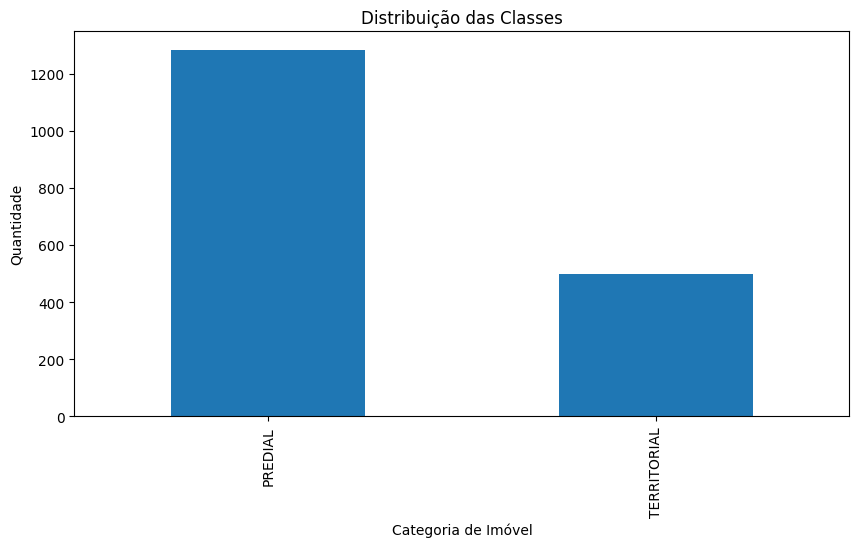


Estatísticas dos pixels (R, G, B):
       pixel_0_R   pixel_0_G   pixel_0_B   pixel_1_R   pixel_1_G   pixel_1_B  \
min     7.000000    0.000000    0.000000    8.000000    0.000000    0.000000   
max   255.000000  255.000000  255.000000  255.000000  255.000000  255.000000   
mean  144.583942  124.927569  117.597417  144.258282  124.638967  117.296463   
std    60.017969   56.242221   55.166919   60.236440   56.524991   55.437096   

       pixel_2_R   pixel_2_G   pixel_2_B   pixel_3_R  ...  pixel_2496_B  \
min     8.000000    0.000000    0.000000    4.000000  ...      0.000000   
max   255.000000  255.000000  255.000000  255.000000  ...    255.000000   
mean  142.786075  123.029759  115.512072  139.864121  ...    117.483436   
std    59.662729   55.748076   54.676305   60.578620  ...     53.097984   

      pixel_2497_R  pixel_2497_G  pixel_2497_B  pixel_2498_R  pixel_2498_G  \
min       8.000000      0.000000      0.000000      7.000000      0.000000   
max     255.000000    255.00000

In [ ]:
# 3 Análise Exploratória de Dados
print("\n=== ANÁLISE EXPLORATÓRIA ===")
print(f"Total de amostras: {len(df)}")
print(f"Total de características: {len(df.columns)-2}")  # exclui filename e label

    # Distribuição das classes
plt.figure(figsize=(10,5))
df['label'].value_counts().plot(kind='bar')
plt.title('Distribuição das Classes')
plt.xlabel('Categoria de Imóvel')
plt.ylabel('Quantidade')
plt.show()

    # Estatísticas dos pixels
pixel_stats = df.drop(columns=['filename', 'label']).describe()
print("\nEstatísticas dos pixels (R, G, B):")
print(pixel_stats.loc[['min', 'max', 'mean', 'std']])



## 🎯 Justificativa do Projeto

O uso de técnicas de **aprendizado de máquina aplicadas ao cadastro territorial multifinalitário** representa uma abordagem promissora para a **classificação automatizada de informações urbanas**. Em vez de depender apenas de processos manuais, que são geralmente custosos e demorados, os modelos de aprendizado de máquina permitem identificar padrões em imagens e dados cadastrais, proporcionando maior **agilidade, escalabilidade e precisão** na gestão urbana.  

Essa integração entre **inteligência artificial** e **dados territoriais** pode apoiar prefeituras e órgãos de planejamento em diversas tarefas, como:  
- Identificação do uso e ocupação do solo;  
- Monitoramento de transformações urbanas;  
- Atualização contínua dos registros cadastrais.  

Com isso, abre-se espaço para **tomadas de decisão mais eficientes**, sustentando **políticas públicas** e iniciativas voltadas para o desenvolvimento de **cidades inteligentes**.

###  Pré-processamento
- **Codificação das classes**: utilização do `LabelEncoder` para transformar os rótulos categóricos em valores numéricos.  
- **Normalização das imagens**: redimensionamento para `50x50` pixels e normalização dos valores RGB no intervalo `[0,1]`.  
- **Divisão dos dados**: separação em conjuntos de treino (60%), validação (20%) e teste (20%).  
- Preparação de duas representações dos dados:
  - **Flatten (1D)** → para modelos tradicionais (Random Forest).  
  - **Formato matricial (50x50x3)** → para modelos de Deep Learning (CNN).  


In [ ]:
# Pré-processamento
X = df.drop(columns=['filename', 'label']).values
y = df['label'].values


In [ ]:
# 4 Codificação das labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# Normalização e reshape
X_normalized = X.reshape(-1, 50, 50, 3).astype('float32') / 255.0
X_flatten = X_normalized.reshape(X_normalized.shape[0], -1)  # Para RandomForest

In [ ]:
# 5. DIVISAO DOS DADOS (60-20-20)
# Divisao para CNN
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_encoded, test_size=0.2, stratify=y_encoded, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=SEED)



# Divisao para RandomForest (mesma proporcao)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_flatten, y_encoded, test_size=0.2, stratify=y_encoded, random_state=SEED)

X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_train_rf, y_train_rf, test_size=0.25, stratify=y_train_rf, random_state=SEED)

O SMOTE (Synthetic Minority Over-sampling Technique) é uma técnica para lidar com desbalanceamento de classes criando novos exemplos sintéticos da classe minoritária, em vez de simplesmente duplicar dados existentes.

In [ ]:
# ========================
# 6.1 RANDOM FOREST COM SMOTE
# ========================
print("\n=== RANDOM FOREST (com SMOTE) ===")

# Aplicar SMOTE no conjunto de treino do RF
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_rf, y_train_rf)


=== RANDOM FOREST (com SMOTE) ===


In [ ]:

print("Distribuição original:", np.bincount(y_train_rf))
print("Distribuição balanceada:", np.bincount(y_train_bal))

Distribuição original: [769 299]
Distribuição balanceada: [769 769]


###  Balanceamento das classes
- Aplicação da técnica **SMOTE (Synthetic Minority Over-sampling Technique)** para lidar com desbalanceamento entre categorias no Random Forest.  

###  Modelagem
- **Random Forest**  
  - Treinamento após balanceamento com SMOTE.  
  - Ajuste de hiperparâmetros básicos (número de árvores, profundidade, mínimo de splits).  

In [ ]:
# Ajustar pesos de classe
class_weights_bal = compute_class_weight('balanced', classes=np.unique(y_train_bal), y=y_train_bal)
class_weight_dict_bal = dict(enumerate(class_weights_bal))

In [ ]:
# Treinar modelo
rf_model_bal = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    min_samples_split=3,
    class_weight=class_weight_dict_bal,
    random_state=SEED,
    n_jobs=-1
)

In [ ]:
rf_model_bal.fit(X_train_bal, y_train_bal)


,n_estimators,100
,criterion,'gini'
,max_depth,25
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Predições
y_pred_rf_bal = rf_model_bal.predict(X_test_rf)
y_proba_rf_bal = rf_model_bal.predict_proba(X_test_rf)

# Relatório de classificação
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test_rf, y_pred_rf_bal, target_names=le.classes_))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     PREDIAL       0.88      0.95      0.91       257
 TERRITORIAL       0.85      0.66      0.74       100

    accuracy                           0.87       357
   macro avg       0.86      0.81      0.83       357
weighted avg       0.87      0.87      0.87       357



In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_test_rf, y_pred_rf_bal)
print("\n=== MATRIZ DE CONFUSÃO ===")
print(cm)



=== MATRIZ DE CONFUSÃO ===
[[245  12]
 [ 34  66]]


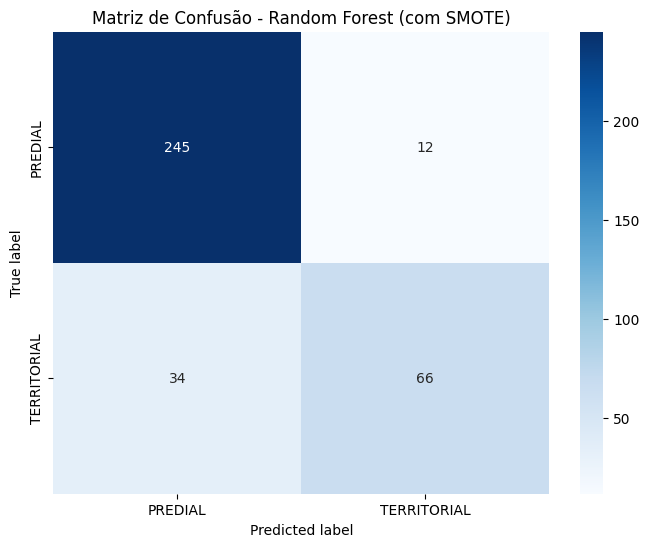

In [ ]:
# Plot da matriz de confusão
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title('Matriz de Confusão - Random Forest (com SMOTE)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

Balanceamento
- Cálculo de **pesos de classe balanceados** para uso no treinamento da CNN.

Modelagem
- **Convolutional Neural Network (CNN)**  
  - Arquitetura com camadas convolucionais, pooling e dropout para reduzir overfitting.  
  - Função de perda: *Sparse Categorical Crossentropy*.  
  - Otimizador: **Adam**.  
  - Estratégias de regularização: *Early Stopping* e *Model Checkpoint*.  


In [ ]:
# =====  Preparar dados para CNN =====
img_size = (50, 50)
X_train_img = X_train.reshape(-1, img_size[0], img_size[1], 3).astype('float32') / 255.0
X_test_img = X_test.reshape(-1, img_size[0], img_size[1], 3).astype('float32') / 255.0
num_classes = len(le.classes_)

In [ ]:
# ===== 6.2. Modelo CNN =====

cnn_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (5,5), activation='relu', padding='same', input_shape=(img_size[0], img_size[1], 3)),
    tf.keras.layers.Conv2D(32, (5,5), activation='relu', padding='same'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPool2D(strides=(2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


cnn_model.summary()


c:\Users\gisel\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy')

In [ ]:
# Treinamento
history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict_bal,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)


# Visualização do treinamento
plt.figure(figsize=(12, 5))

Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6830 - loss: 0.8403

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.7125 - loss: 0.6898 - val_accuracy: 0.7219 - val_loss: 0.5286
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.7200 - loss: 0.5020 - val_accuracy: 0.7219 - val_loss: 0.4880
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7177 - loss: 0.4323

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 0.7481 - loss: 0.4213 - val_accuracy: 0.8624 - val_loss: 0.4618
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8394 - loss: 0.3987

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.8305 - loss: 0.3927 - val_accuracy: 0.8792 - val_loss: 0.4211
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - accuracy: 0.8596 - loss: 0.3540 - val_accuracy: 0.8792 - val_loss: 0.3625
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8808 - loss: 0.3177

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.8773 - loss: 0.3214 - val_accuracy: 0.9017 - val_loss: 0.3006
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - accuracy: 0.8989 - loss: 0.2746 - val_accuracy: 0.9017 - val_loss: 0.2469
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.9110 - loss: 0.2487 - val_accuracy: 0.8539 - val_loss: 0.3315
Epoch 9/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9293 - loss: 0.2004

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.9232 - loss: 0.2173 - val_accuracy: 0.9213 - val_loss: 0.2158
Epoch 10/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9526 - loss: 0.1512

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step - accuracy: 0.9335 - loss: 0.1912 - val_accuracy: 0.9242 - val_loss: 0.2039
Epoch 11/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.9316 - loss: 0.1871 - val_accuracy: 0.9185 - val_loss: 0.2158
Epoch 12/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step - accuracy: 0.9466 - loss: 0.1590 - val_accuracy: 0.9045 - val_loss: 0.2055
Epoch 13/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9553 - loss: 0.1285

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - accuracy: 0.9494 - loss: 0.1484 - val_accuracy: 0.9354 - val_loss: 0.1790
Epoch 14/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9671 - loss: 0.0998

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 345ms/step - accuracy: 0.9597 - loss: 0.1146 - val_accuracy: 0.9410 - val_loss: 0.1777
Epoch 15/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 0.9728 - loss: 0.0898 - val_accuracy: 0.9354 - val_loss: 0.1810


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

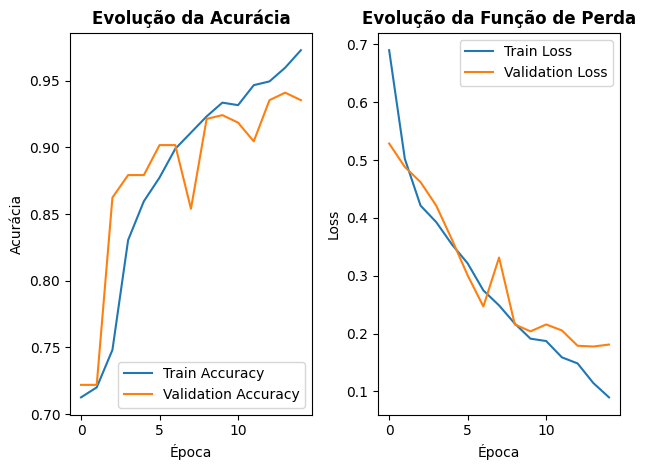

In [ ]:
# Gráfico de acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Evolução da Acurácia', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

# Gráfico de loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolução da Função de Perda', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=300)
plt.show()

In [ ]:
# Avaliação no conjunto de teste
print("\n[INFO] Avaliando a CNN no conjunto de teste...")
test_loss, test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"\n[RESULTADO] Acurácia no teste: {test_acc:.4f}")
print(f"[RESULTADO] Loss no teste: {test_loss:.4f}")


[INFO] Avaliando a CNN no conjunto de teste...

[RESULTADO] Acurácia no teste: 0.9216
[RESULTADO] Loss no teste: 0.1830


In [ ]:
# Predições
y_pred_cnn = cnn_model.predict(X_test).argmax(axis=1)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


###  Avaliação dos modelos
- Avaliação quantitativa com métricas:  
  - **Acurácia, Precisão, Recall, F1-score (macro)**  
  - **MCC (Matthews Correlation Coefficient)**  
  - **Kappa de Cohen**  
  - **AUC (macro, multi-classe)**  
- Visualização dos resultados:  
  - Matrizes de confusão.  
  - Curvas de aprendizado (loss e acurácia ao longo das épocas).  
- Comparação final em tabela consolidando as métricas entre Random Forest e CNN.


=== RELATÓRIO DE CLASSIFICAÇÃO - CNN ===
              precision    recall  f1-score   support

     PREDIAL       0.96      0.93      0.94       257
 TERRITORIAL       0.83      0.90      0.87       100

    accuracy                           0.92       357
   macro avg       0.90      0.91      0.91       357
weighted avg       0.92      0.92      0.92       357



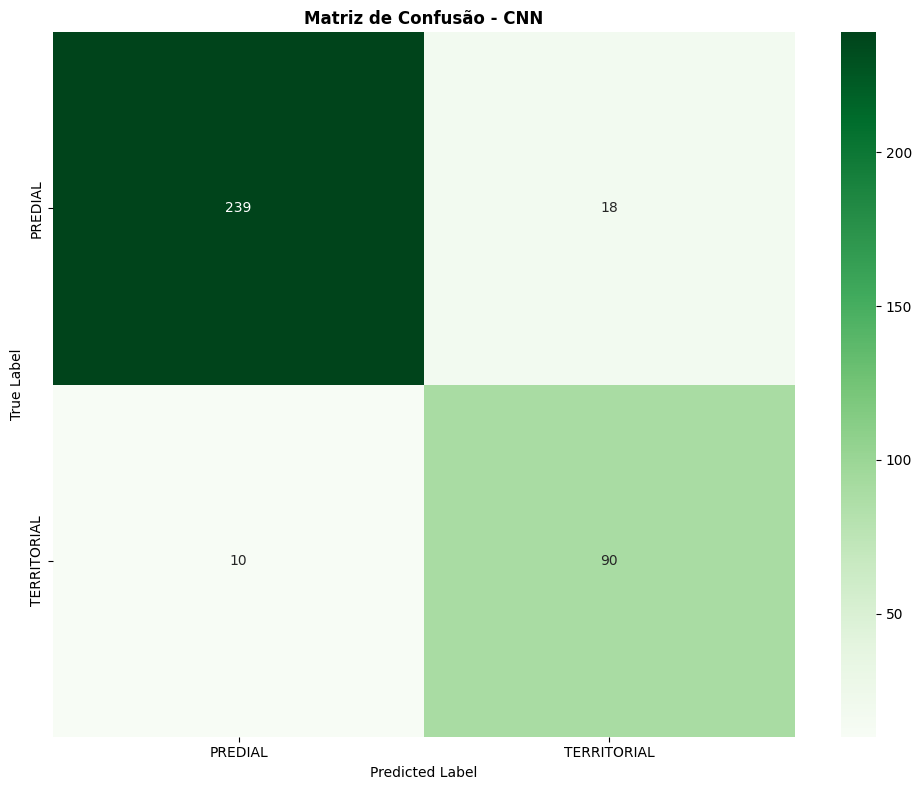

In [ ]:
#Relatório de classificação
print("\n=== RELATÓRIO DE CLASSIFICAÇÃO - CNN ===")
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Matriz de Confusão - CNN', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn.png', dpi=300)
plt.show()


In [ ]:
print("\n[INFO] Comparando os modelos...")

# Criar tabela comparativa
results = pd.DataFrame({
    'Modelo': ['Random Forest', 'CNN'],
    'Acurácia': [
        accuracy_score(y_test_rf, y_pred_rf_bal),
        accuracy_score(y_test, y_pred_cnn)
    ],
    'Precisão (macro)': [
        precision_score(y_test_rf, y_pred_rf_bal, average='macro'),
        precision_score(y_test, y_pred_cnn, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y_test_rf, y_pred_rf_bal, average='macro'),
        recall_score(y_test, y_pred_cnn, average='macro')
    ],
    'F1-score (macro)': [
        f1_score(y_test_rf, y_pred_rf_bal, average='macro'),
        f1_score(y_test, y_pred_cnn, average='macro')
    ],
    'MCC': [
        matthews_corrcoef(y_test_rf, y_pred_rf_bal),
        matthews_corrcoef(y_test, y_pred_cnn)
    ]
})


[INFO] Comparando os modelos...


In [ ]:

print("\n=== COMPARAÇÃO DOS MODELOS ===")
print(results.to_markdown(index=False))


=== COMPARAÇÃO DOS MODELOS ===
| Modelo        |   Acurácia |   Precisão (macro) |   Recall (macro) |   F1-score (macro) |      MCC |
|:--------------|-----------:|-------------------:|-----------------:|-------------------:|---------:|
| Random Forest |   0.871148 |           0.862145 |         0.806654 |           0.827876 | 0.666493 |
| CNN           |   0.921569 |           0.896586 |         0.914981 |           0.905024 | 0.811358 |


## ⚙️ Metodologia

A metodologia deste trabalho envolveu cinco etapas principais. Inicialmente, procedeu-se à preparação dos dados, com a importação das bibliotecas, definição de sementes para reprodutibilidade e carregamento da base tabular (`dataset_rgb.csv`). Nessa etapa, realizaram-se análises exploratórias, como a distribuição das classes e estatísticas dos pixels das imagens.  

Na fase de pré-processamento, os rótulos foram codificados numericamente por meio do `LabelEncoder`, as imagens foram normalizadas (50x50 pixels, valores RGB entre 0 e 1) e os dados foram divididos em conjuntos de treino, validação e teste (60%-20%-20%). Para adequar-se a diferentes modelos, os dados foram representados de duas formas: vetores achatados (para Random Forest) e tensores tridimensionais (para CNN).  

Em seguida, foi aplicado balanceamento das classes: **SMOTE** para o Random Forest e cálculo de **pesos balanceados** para a CNN. Quanto à modelagem, dois algoritmos foram empregados: (i) **Random Forest**, configurado com parâmetros como profundidade máxima e mínimo de splits; e (ii) uma **Convolutional Neural Network (CNN)** composta por camadas convolucionais, pooling e dropout, treinada com otimizador Adam, função de perda *Sparse Categorical Crossentropy* e estratégias de regularização como *Early Stopping*.  

Por fim, os modelos foram avaliados com base em múltiplas métricas: **Acurácia, Precisão, Recall, F1-score (macro), MCC, Kappa de Cohen e AUC**. Foram também geradas matrizes de confusão e curvas de aprendizado, permitindo uma análise comparativa entre os desempenhos de Random Forest e CNN.  
